In [11]:
!pip install pandas numpy matplotlib

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set seed so all students get the exact same random numbers
np.random.seed(42)

# 1. Create an array of 100 days (Day 1 to 100)
days = np.arange(1, 101)
print(days)

# 2. Simulate 100 days of Temperatures (Average 75 degrees, standard deviation of 10)
temperatures = np.random.normal(loc=75, scale=5, size=100)
temperatures = np.round(temperatures, 1) # Round to 1 decimal place

# 3. Simulate Sales (Ice cream goes up when it's hot, coffee goes down)
# Add a little random noise so the data doesn't look completely artificial
ice_cream_sales = (temperatures * 4) + np.random.normal(0, 20, 100)
coffee_sales = (400 - (temperatures * 3)) + np.random.normal(0, 15, 100)
lemonade_sales = (temperatures * 5) + np.random.normal(0, 20, 100)

# Clean up negative sales (can't sell less than 0 items)
ice_cream_sales = np.maximum(ice_cream_sales, 0)
coffee_sales = np.maximum(coffee_sales, 0)
lemonade_sales = np.maximum(lemonade_sales, 0)

print(f"First 5 temperatures: {temperatures[:5]}")
print(f"First 5 days of ice cream sales: {ice_cream_sales[:5]}")
print(f"First 5 days of coffee sales: {coffee_sales[:5]}")
print(f"First 5 days of lemonade sales: {lemonade_sales[:5]}")

[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100]
First 5 temperatures: [77.5 74.3 78.2 82.6 73.8]
First 5 days of ice cream sales: [281.69258516 288.78709354 305.94570967 314.35445462 291.97428577]
First 5 days of coffee sales: [172.86681041 185.5117679  181.64576865 168.00703078 157.93495948]
First 5 days of lemonade sales: [370.92009978 360.2963792  405.9458721  425.20740531 368.58196812]


In [13]:
# 1. Create the DataFrame to organize our arrays into columns
df = pd.DataFrame({
    'Day': days,
    'Temperature': temperatures,
    'Ice_Cream': np.round(ice_cream_sales),
    'Coffee': np.round(coffee_sales),
    'Lemonade': np.round(lemonade_sales)
})

# 2. Basic Exploration 
print(df.head())
newdf = df.describe()
print(newdf)
print(newdf["Day"]["mean"])

# 3. Feature Engineering: Create a new column for Total Items Sold
df['Total_Sales'] = df['Ice_Cream'] + df['Coffee'] + df['Lemonade']

# 4. Data Filtering: Let's analyze "Heatwave" days (over 85 degrees)
heatwave_df = df[df['Temperature'] > 85]

# Find the single day with the highest total sales
best_day = df[df['Total_Sales'] == df['Total_Sales'].max()]

print("Our Best Sales Day:")
print(best_day)

   Day  Temperature  Ice_Cream  Coffee  Lemonade
0    1         77.5      282.0   173.0     371.0
1    2         74.3      289.0   186.0     360.0
2    3         78.2      306.0   182.0     406.0
3    4         82.6      314.0   168.0     425.0
4    5         73.8      292.0   158.0     369.0
              Day  Temperature   Ice_Cream      Coffee    Lemonade
count  100.000000   100.000000  100.000000  100.000000  100.000000
mean    50.500000    74.484000  298.360000  177.580000  374.520000
std     29.011492     4.540541   24.461274   19.147055   26.243799
min      1.000000    61.900000  244.000000  130.000000  309.000000
25%     25.750000    72.000000  281.500000  167.750000  358.750000
50%     50.500000    74.350000  298.000000  179.000000  373.500000
75%     75.250000    77.050000  312.500000  190.000000  391.000000
max    100.000000    84.300000  369.000000  225.000000  440.000000
50.5
Our Best Sales Day:
   Day  Temperature  Ice_Cream  Coffee  Lemonade  Total_Sales
6    7         8

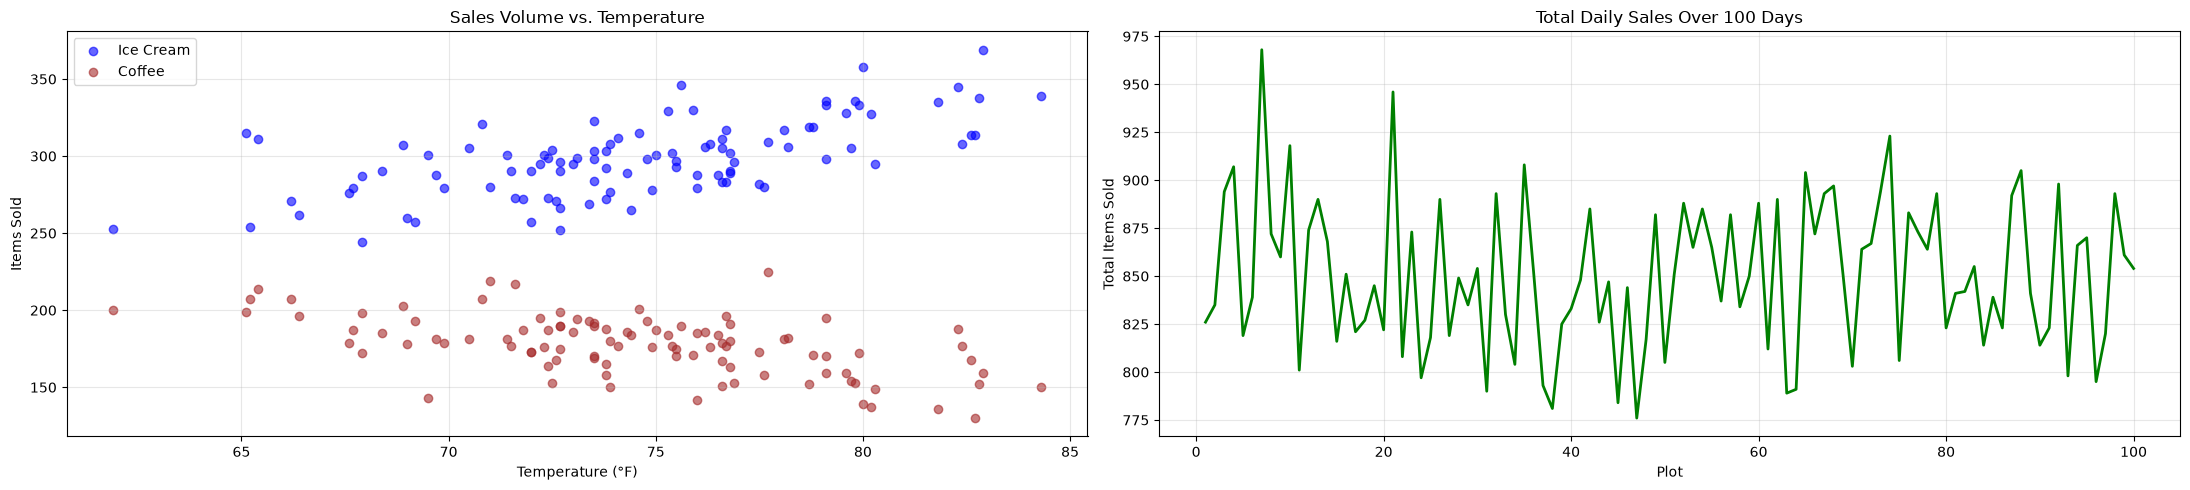

In [15]:
# Create a figure with two side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 5))

# --- Plot 1: Scatter Plot (Correlation) ---
# Does temperature really affect sales? Let's prove it visually.
ax1.scatter(df['Temperature'], df['Ice_Cream'], color='blue', alpha=0.6, label='Ice Cream')
ax1.scatter(df['Temperature'], df['Coffee'], color='brown', alpha=0.6, label='Coffee')
ax1.set_title('Sales Volume vs. Temperature')
ax1.set_xlabel('Temperature (°F)')
ax1.set_ylabel('Items Sold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Plot 2: Line Graph (Trends over Time) ---
# How did our total sales look over the 100 days?
ax2.plot(df['Day'], df['Total_Sales'], color='green', linewidth=2)
ax2.set_title('Total Daily Sales Over 100 Days')
ax2.set_xlabel('Plot')
ax2.set_ylabel('Total Items Sold')
ax2.grid(True, alpha=0.3)



# Display the graphs cleanly
plt.tight_layout()
plt.show()

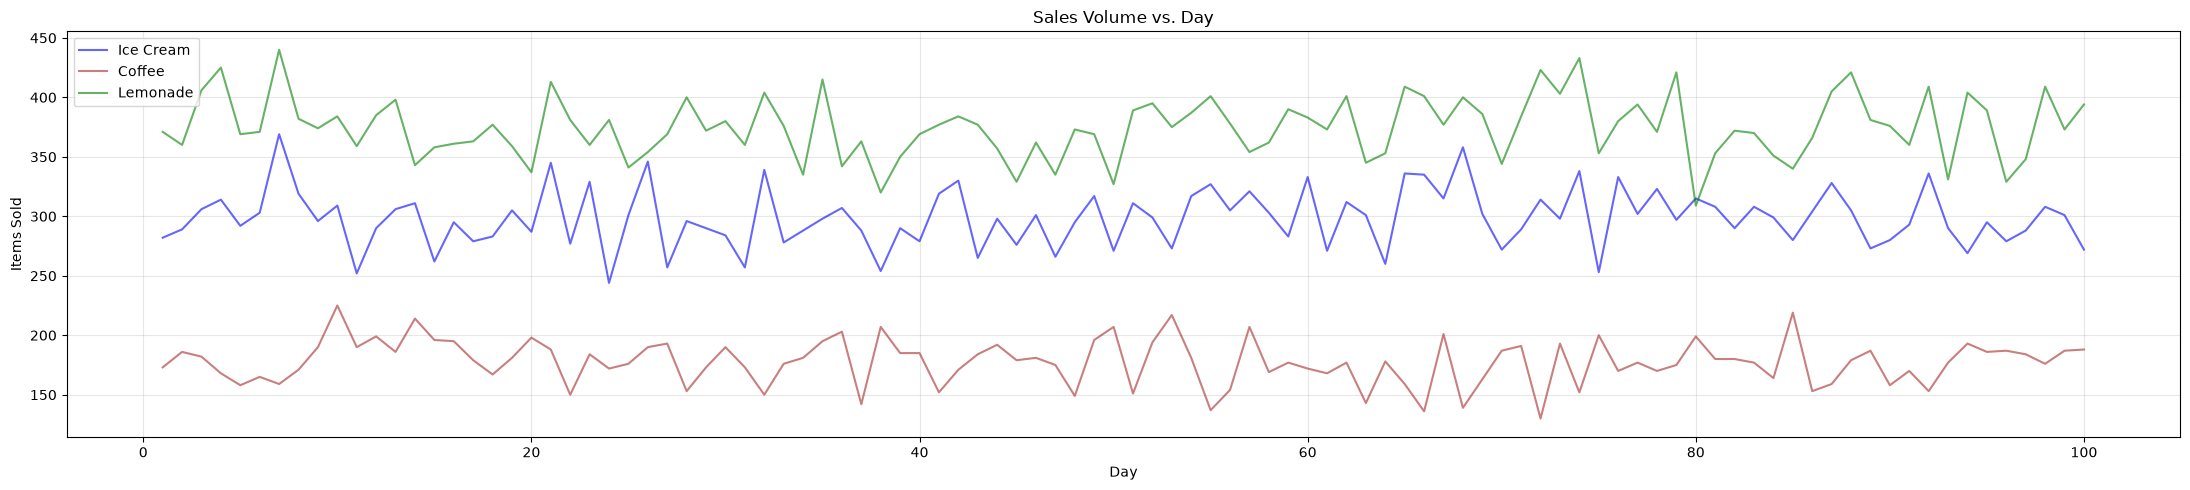

In [20]:
fig, (ax1) = plt.subplots(1, figsize=(22, 5))

# --- Plot 1: Scatter Plot (Correlation) ---
# Does temperature really affect sales? Let's prove it visually.
ax1.plot(df['Day'], df['Ice_Cream'], color='blue', alpha=0.6, label='Ice Cream')
ax1.plot(df['Day'], df['Coffee'], color='brown', alpha=0.6, label='Coffee')
ax1.plot(df['Day'], df['Lemonade'], color='green', alpha=0.6, label='Lemonade')
ax1.set_title('Sales Volume vs. Day')
ax1.set_xlabel('Day')
ax1.set_ylabel('Items Sold')
ax1.legend()
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()